In [13]:
# Install packages (Run only once in Colab)
!pip -q install qiskit qiskit-aer pylatexenc matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.5 MB/s eta 0:00:00


In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import numpy as np
import matplotlib.pyplot as plt
import itertools

backend = AerSimulator()


# --------------------------------------------------------
# Classical Simon Function
# --------------------------------------------------------

def classical_f(x, secret_int):
    return min(x, x ^ secret_int)


# --------------------------------------------------------
# Build Simon Oracle
# --------------------------------------------------------

def build_simon_oracle(secret):

    n = len(secret)
    secret_int = int(secret, 2)

    dimension = 1 << (2 * n)

    permutation = np.zeros((dimension, dimension))

    for x in range(1 << n):

        fx = classical_f(x, secret_int)

        for y in range(1 << n):

            input_index = x | (y << n)

            output_index = x | ((y ^ fx) << n)

            permutation[output_index, input_index] = 1

    gate = UnitaryGate(permutation, label="Simon Oracle")

    oracle = QuantumCircuit(2 * n)

    oracle.append(gate, range(2 * n))

    return oracle


# --------------------------------------------------------
# Build Complete Simon Circuit
# --------------------------------------------------------

def build_simon_circuit(secret):

    n = len(secret)

    qc = QuantumCircuit(2 * n, n)

    qc.h(range(n))

    oracle = build_simon_oracle(secret)

    qc.compose(oracle, inplace=True)

    qc.h(range(n))

    qc.measure(range(n), range(n))

    return qc


# --------------------------------------------------------
# Decode Oracle Output
# --------------------------------------------------------

def decode_output(statevector, n):

    probabilities = statevector.probabilities_dict()

    dominant = max(probabilities, key=probabilities.get)

    value = int(dominant, 2)

    input_bits = value & ((1 << n) - 1)

    output_bits = (value >> n) & ((1 << n) - 1)

    return input_bits, output_bits


# --------------------------------------------------------
# Collect Independent Measurement Equations
# --------------------------------------------------------

def binary_rank(matrix):

    matrix = [row[:] for row in matrix]

    rank = 0

    if len(matrix) == 0:
        return 0

    cols = len(matrix[0])

    for col in range(cols):

        pivot = None

        for row in range(rank, len(matrix)):

            if matrix[row][col]:

                pivot = row

                break

        if pivot is None:
            continue

        matrix[rank], matrix[pivot] = matrix[pivot], matrix[rank]

        for row in range(len(matrix)):

            if row != rank and matrix[row][col]:

                matrix[row] = [
                    a ^ b
                    for a, b in zip(matrix[row], matrix[rank])
                ]

        rank += 1

    return rank


def collect_independent_equations(
        counts,
        n,
        required,
        existing_rows=None):

    if existing_rows is None:
        existing_rows = []

    equations = existing_rows[:]

    for bitstring in sorted(counts):

        if bitstring == "0" * n:
            continue

        row = [int(bit) for bit in bitstring]

        trial = equations + [row]

        if binary_rank(trial) > binary_rank(equations):

            equations.append(row)

        if len(equations) >= required:
            break

    return equations


# --------------------------------------------------------
# GF(2) Solver
# --------------------------------------------------------

def gf2_solve_secret(rows, n):

    matrix = np.array(rows, dtype=int)

    for candidate in range(1, 2 ** n):

        secret = np.array(
            list(
                map(
                    int,
                    format(candidate, f'0{n}b')
                )
            )
        )

        valid = True

        for row in matrix:

            if np.dot(row, secret) % 2 != 0:

                valid = False

                break

        if valid:

            return secret.tolist()

    return [0] * n


# --------------------------------------------------------
# Print Binary Equations
# --------------------------------------------------------

def print_equations(rows):

    print("\nIndependent Equations\n")

    for row in rows:

        print(
            ''.join(map(str, row)),
            "· s = 0 (mod 2)"
        )

Quantum Oracle Circuit



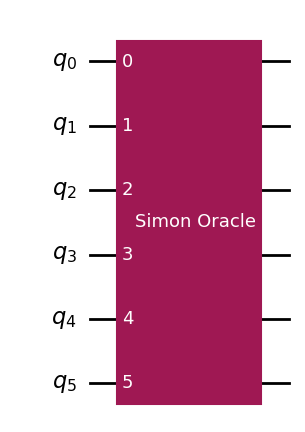


Truth Table Verification

f(000) = 000
f(100) = 010
f(010) = 010
f(110) = 000
f(001) = 001
f(101) = 011
f(011) = 011
f(111) = 001

Oracle Property Verified : True


In [15]:
secret = "110"

n = len(secret)

oracle = build_simon_oracle(secret)

print("Quantum Oracle Circuit\n")

display(oracle.draw("mpl"))

print("\nTruth Table Verification\n")

table = {}

for bits in itertools.product([0, 1], repeat=n):

    circuit = QuantumCircuit(2 * n)

    for index, bit in enumerate(bits):

        if bit:
            circuit.x(index)

    final_state = Statevector.from_instruction(
        circuit.compose(oracle)
    )

    x, fx = decode_output(final_state, n)

    x_string = format(x, f'0{n}b')

    fx_string = format(fx, f'0{n}b')

    table[x_string] = fx_string

    print(f"f({x_string}) = {fx_string}")

secret_int = int(secret, 2)

verified = True

for key in table:

    partner = format(
        int(key, 2) ^ secret_int,
        f'0{n}b'
    )

    if table[key] != table[partner]:

        verified = False

        break

print("\nOracle Property Verified :", verified)

Simon's Algorithm Circuit



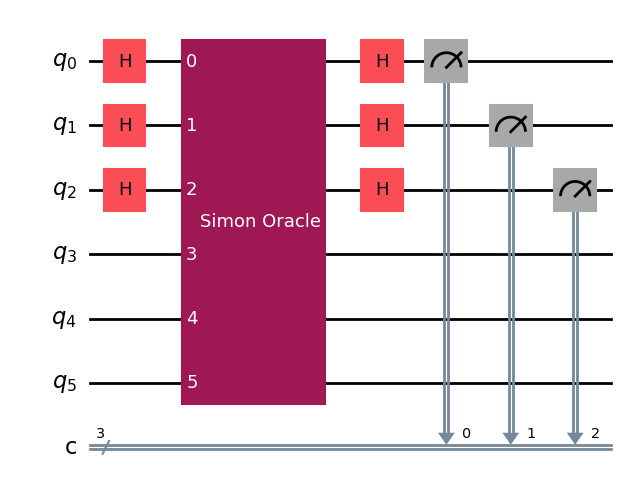


Measurement Counts

{'110': 237, '111': 266, '001': 262, '000': 259}

Independent Equations

001 · s = 0 (mod 2)
110 · s = 0 (mod 2)

Number of Independent Equations Collected : 2


In [16]:
# Exercise 2

secret = "110"

n = len(secret)

# Build Simon Circuit
qc = build_simon_circuit(secret)

print("Simon's Algorithm Circuit\n")

display(qc.draw("mpl"))

# Execute Circuit
compiled = transpile(qc, backend)

job = backend.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts\n")

print(counts)

# Plot Histogram
plot_histogram(counts)

plt.show()

# Collect Independent Equations
required_equations = n - 1

equations = collect_independent_equations(
    counts=counts,
    n=n,
    required=required_equations
)

print_equations(equations)

print("\nNumber of Independent Equations Collected :", len(equations))

4-Bit Simon Circuit



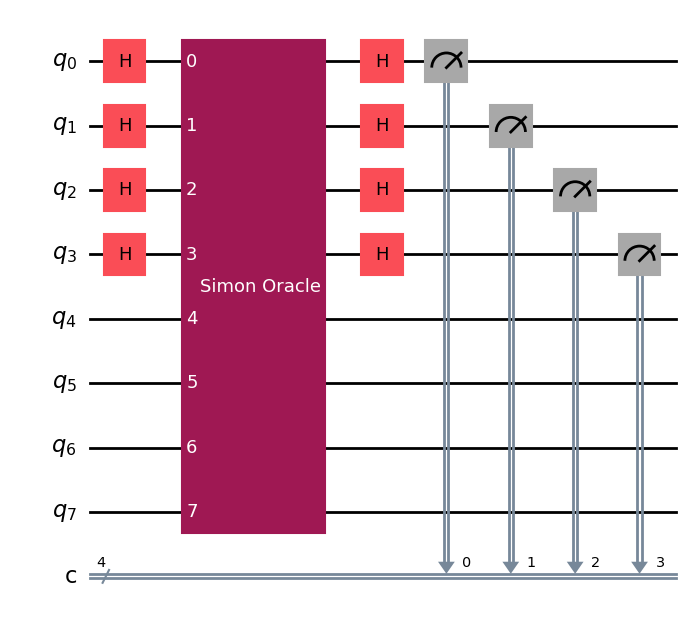


Measurement Counts

{'1001': 514, '0100': 514, '0000': 524, '0111': 499, '0011': 495, '1110': 530, '1101': 482, '1010': 538}

Independent Equations

0011 · s = 0 (mod 2)
0100 · s = 0 (mod 2)
1001 · s = 0 (mod 2)

Recovered Secret String
1011

Actual Secret String
1011

Verification Successful


In [17]:
# Exercise 3

secret = "1011"

n = len(secret)

# Build Simon Circuit
qc = build_simon_circuit(secret)

print("4-Bit Simon Circuit\n")

display(qc.draw("mpl"))

# Execute Circuit
compiled = transpile(qc, backend)

job = backend.run(compiled, shots=4096)

result = job.result()

counts = result.get_counts()

print("\nMeasurement Counts\n")

print(counts)

# Plot Histogram
plot_histogram(counts)

plt.show()

# Collect n-1 Independent Equations
required_equations = n - 1

equations = collect_independent_equations(
    counts=counts,
    n=n,
    required=required_equations
)

print_equations(equations)

# Solve for Secret String
recovered_secret = gf2_solve_secret(
    equations,
    n
)

print("\nRecovered Secret String")

print("".join(map(str, recovered_secret)))

print("\nActual Secret String")

print(secret)

# Verification
if "".join(map(str, recovered_secret)) == secret:
    print("\nVerification Successful")
else:
    print("\nVerification Failed")

Oracle Query Comparison

Bits      Classical           Simon's Algorithm   
2         2.00                2                   
3         2.83                3                   
4         4.00                4                   
5         5.66                5                   
6         8.00                6                   
7         11.31               7                   
8         16.00               8                   
9         22.63               9                   
10        32.00               10                  


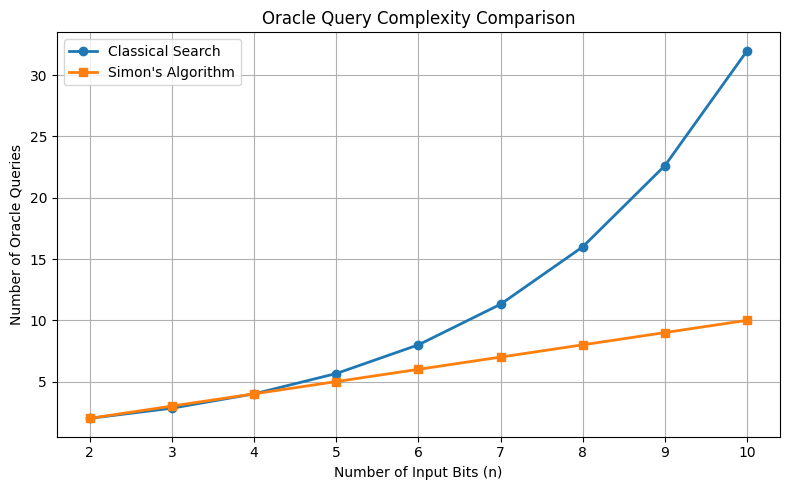


Approximate Speedup

2 bits : 1.00x
3 bits : 0.94x
4 bits : 1.00x
5 bits : 1.13x
6 bits : 1.33x
7 bits : 1.62x
8 bits : 2.00x
9 bits : 2.51x
10 bits : 3.20x


In [18]:
# Exercise 4

import numpy as np
import matplotlib.pyplot as plt

# Different problem sizes
bit_lengths = np.arange(2, 11)

# Approximate query complexities
classical_queries = [2 ** (n / 2) for n in bit_lengths]
quantum_queries = bit_lengths

# Display comparison table
print("Oracle Query Comparison\n")

print("{:<10}{:<20}{:<20}".format(
    "Bits",
    "Classical",
    "Simon's Algorithm"
))

for n, c, q in zip(bit_lengths, classical_queries, quantum_queries):

    print("{:<10}{:<20.2f}{:<20}".format(
        n,
        c,
        q
    ))

# Plot Comparison
plt.figure(figsize=(8,5))

plt.plot(
    bit_lengths,
    classical_queries,
    marker='o',
    linewidth=2,
    label='Classical Search'
)

plt.plot(
    bit_lengths,
    quantum_queries,
    marker='s',
    linewidth=2,
    label="Simon's Algorithm"
)

plt.title("Oracle Query Complexity Comparison")

plt.xlabel("Number of Input Bits (n)")

plt.ylabel("Number of Oracle Queries")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# Calculate Speedup
print("\nApproximate Speedup\n")

for n, c, q in zip(bit_lengths, classical_queries, quantum_queries):

    speedup = c / q

    print(
        f"{n} bits : {speedup:.2f}x"
    )

Running Simon's Algorithm for Secret String : 1011

Quantum Circuit



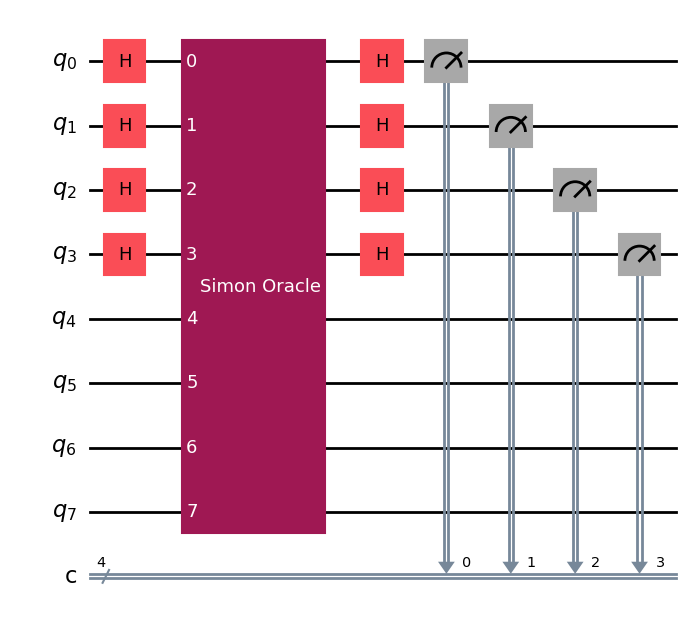


Measurement Counts

{'0000': 496, '1001': 521, '1110': 536, '1010': 495, '0011': 518, '0111': 559, '0100': 481, '1101': 490}

Independent Equations

0011 · s = 0 (mod 2)
0100 · s = 0 (mod 2)
1001 · s = 0 (mod 2)

Recovered Secret String
1011

Verification
Recovery Successful


Running Simon's Algorithm for Secret String : 0000

Special Case Detected
The secret string contains only zeros.
The oracle behaves as a one-to-one function.
Recovered Secret : 0000


In [19]:
# Exercise 5

def generalized_simon(secret):

    n = len(secret)

    print("=" * 55)
    print(f"Running Simon's Algorithm for Secret String : {secret}")
    print("=" * 55)

    # Edge Case
    if secret == "0" * n:

        print("\nSpecial Case Detected")
        print("The secret string contains only zeros.")
        print("The oracle behaves as a one-to-one function.")
        print("Recovered Secret :", secret)

        return

    # Build Circuit
    qc = build_simon_circuit(secret)

    print("\nQuantum Circuit\n")

    display(qc.draw("mpl"))

    # Execute Circuit
    compiled = transpile(qc, backend)

    job = backend.run(compiled, shots=4096)

    result = job.result()

    counts = result.get_counts()

    print("\nMeasurement Counts\n")

    print(counts)

    # Plot Histogram
    plot_histogram(counts)

    plt.show()

    # Collect Equations
    equations = collect_independent_equations(
        counts=counts,
        n=n,
        required=n-1
    )

    print_equations(equations)

    # Recover Secret
    recovered = gf2_solve_secret(
        equations,
        n
    )

    recovered_secret = "".join(map(str, recovered))

    print("\nRecovered Secret String")

    print(recovered_secret)

    print("\nVerification")

    if recovered_secret == secret:

        print("Recovery Successful")

    else:

        print("Recovery Failed")


# ----------------------------------------------------
# Test Cases
# ----------------------------------------------------

generalized_simon("1011")

print("\n")

generalized_simon("0000")